# 3D field interpolation

This short tutorial demonstrates how to use `smudgy` to interpolate a particle field to arbitrary coordinates. The following examples are shown:

+ Interpolation of a single __scalar__ field to a regular 3D grid of query points.

`smudgy.utils` offers a helper function {py:func}`~smudgy.utils.create_grid_3d` (similar functions are available for 1D and 2D) to quickly construct equidistant coordinates. However, arbitrary coordinates can also be passed to the relevant methods.

First, let's import all the necessary packages and modules:

In [1]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np

import smudgy as sm
from smudgy.utils import create_grid_3d

[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.13.14


[I 08/17/26 13:26:43.095 2419277] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [2]:
try:
    plt.style.use('custom')
except:
    pass
%matplotlib inline
%config InlineBackend.figure_format='retina'


## Interpolating a single scalar field

Let's generate a set of particles with (random) 2D positions, weights set to ones, and field values within a periodic box of size 1. As an example we assign each particle $j$ a field value $f_j = f(x_j,y_j,z_j)=\sin(2 \pi x_j) \cos(2 \pi y_j) \cos(2 \pi z_j)$ depending on their spatial coordinates.

In [3]:
boxsize = 1.0
N = 1000
positions = np.random.uniform(0.0, boxsize, size=(N, 3))
weights = np.ones(N)

field_1 = np.sin(2 * np.pi * positions[:, 0]) \
    * np.cos(2 * np.pi * positions[:, 1]) \
    * np.cos(2 * np.pi * positions[:, 2])
field_2 = -field_1
field_3 = field_1 * 3

Then, we initialize a {py:class}`~smudgy.pointcloud.PointCloud` instance and globally set the structure to isotropic, the kernel to a cubic spline and the number of neighbors to use in computations to 32.

In [4]:
pc = sm.PointCloud(positions,
                   weights,
                   boxsize=boxsize).\
    global_setup(kernel_name='cubic_spline',
                 structure='covariant',
                 num_neighbors=32)

[Taichi] Starting on arch=metal
[smudgy] Set taichi backend
[smudgy] Using 1 MPI rank
[smudgy] Initialized 3d PointCloud with 1000 particles in periodic box of size=[1. 1. 1.]
[smudgy] Set structure to 'covariant'
[smudgy] Set kernel to 'cubic_spline'
[smudgy] Set number of neighbors to 32


:::{tip}
You can disable the verbose output by either setting it during initialization `pc = PointCloud(..., verbose=False)` or overwriting it at any time with `pc.verbose = False`.
:::

Next, we compute the relevant information required for interpolation. Remembering the interpolation formula, we need the smoothing lengths $h_j$ and density $\rho_j$ of every particle,

$$
f(\mathbf{x}_i) = \sum_{j}^{n} \frac{w_j}{\rho_j} \, f_j \, W\big(\mathbf{x}_i - \mathbf{x}_j;\ h_j\big).
$$

Since we have already set the necessary parameters globally, we can simply call:

In [5]:
pc.compute_smoothing()
pc.compute_density()

[smudgy] Building kd-tree from positions
[smudgy] Computing smoothing tensors from 32 neighbors
[smudgy] Computing density using covariant 'cubic_spline' kernel


Next, we construct an array of query positions with the help of {py:func}`~smudgy.utils.create_grid_2d` and interpolate the field values at those coordinates

In [6]:
ngrid = 128
query_positions = create_grid_3d(ngrid, boxsize=boxsize) # shape = (ngrid ** 3, 3)

query_values = pc.interpolate(fields=[field_1, field_2, field_3],
                                     query_positions=query_positions) # shape = (ngrid ** 3, 3)
print(query_values.shape)

[smudgy] Interpolating fields at query positions using covariant 'cubic_spline' kernel
(2097152, 3)


Note that we could have achieved the same by first register the field as an attribute to the {py:class}`~smudgy.pointcloud.PointCloud` instance and then call it by name:

In [7]:
pc.add_fields(names=['field_1', 'field_2', 'field_3'], 
              values=[field_1, field_2, field_3])

query_values = pc.interpolate(
    fields=['field_1', 'field_2', 'field_3'], 
    query_positions=query_positions) # shape = (ngrid ** 3, 3)

[smudgy] Interpolating fields at query positions using covariant 'cubic_spline' kernel


After reshaping we can plot the original particles (gray) and the stacked (summed) field values at the query positions:

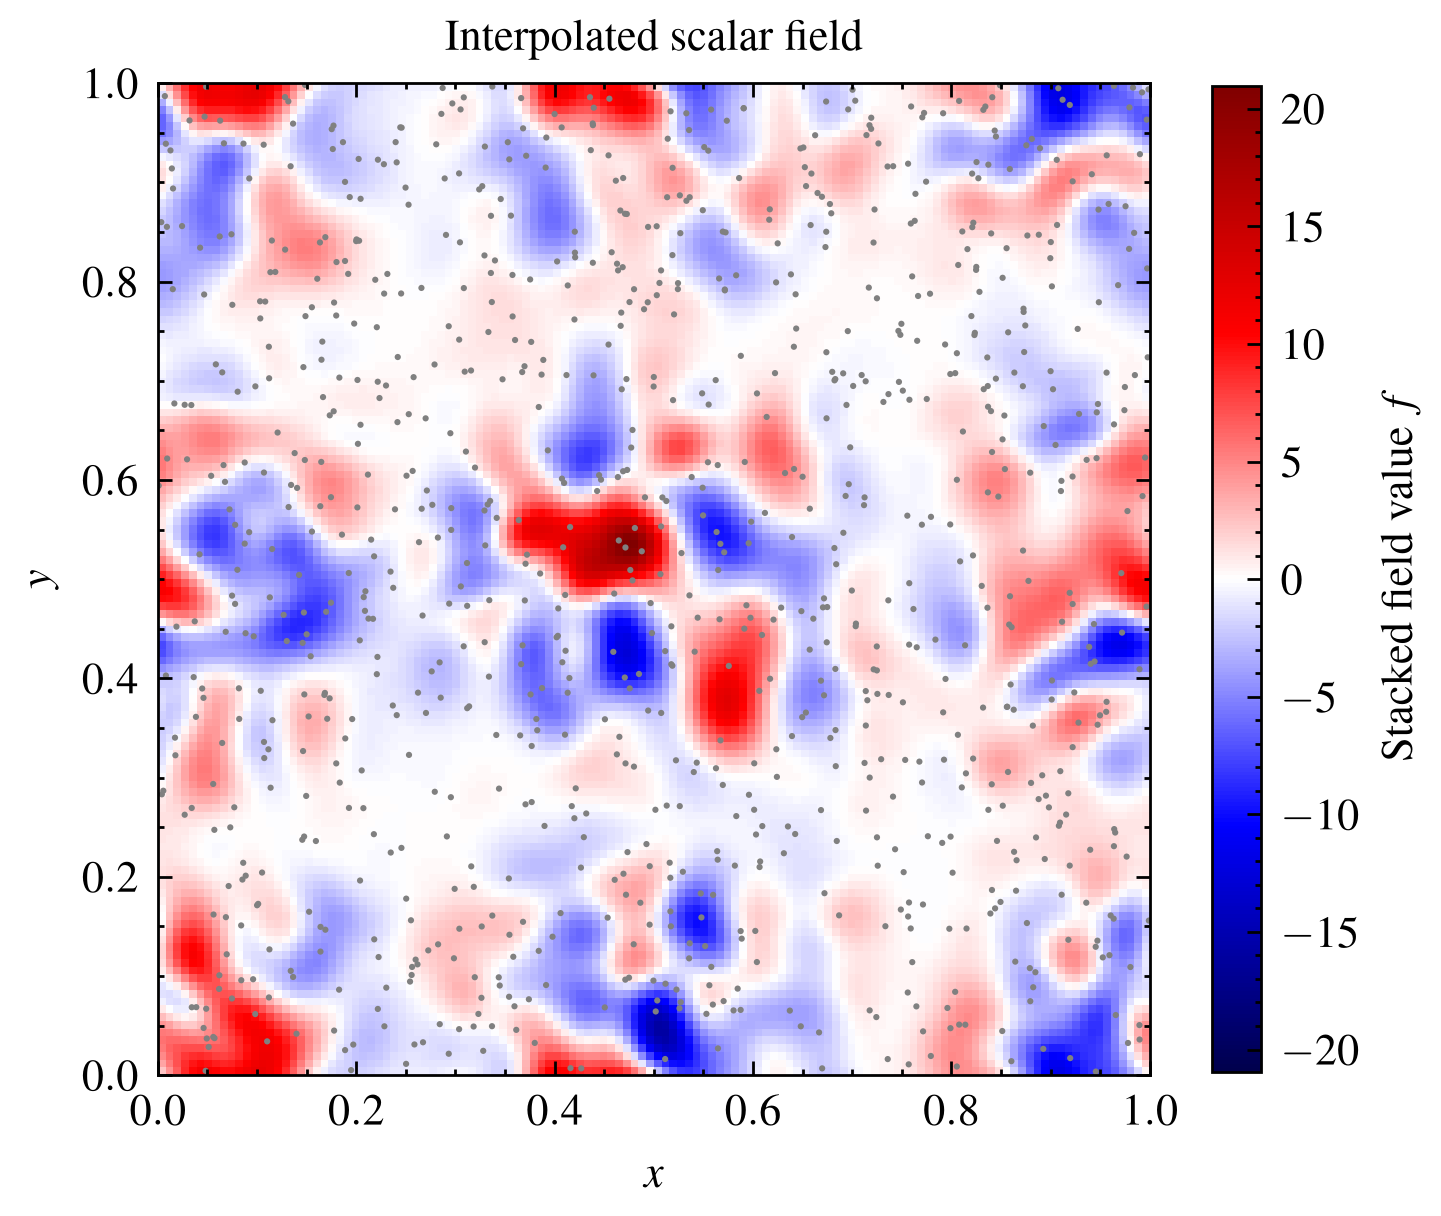

In [8]:
image = query_values[:, 0].reshape((ngrid, ngrid, ngrid)).T

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_title('Interpolated scalar field')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

im = ax.imshow(image.sum(axis=-1), origin='lower', extent=(0, boxsize, 0, boxsize), cmap='seismic',
               norm=colors.CenteredNorm())
ax.scatter(positions[:, 0], positions[:, 1], s=5, color='gray', edgecolors='none')
cax = plt.colorbar(im, ax=ax, shrink=0.8)
cax.set_label(r'Stacked field value $f$')

plt.show()